# Seasonal Agriculture Performance Analysis
**VOIS / AICTE Batch 1 (2026–2027) — Major Project**

---

## 1. Problem framing

Agricultural output is shaped by the season in which a crop is grown. India's cropping
calendar splits into three seasons — **Kharif** (monsoon, Jun–Oct), **Rabi** (winter,
Nov–Mar) and **Zaid** (summer, Mar–Jun) — and each brings a different combination of
rainfall, temperature, humidity and market conditions.

The dataset given to us records 4,000 farm-level observations, but in raw form it does not
say *how* performance differs between these seasons. This notebook investigates that
question.

## 2. Analytical questions

Rather than a generic exploration, the analysis is organised around eight specific
questions:

| # | Question |
|---|----------|
| Q1 | How do environmental conditions (rainfall, temperature, humidity, soil moisture) differ across the three seasons? |
| Q2 | Does crop yield differ by season once the difference in crop mix is accounted for? |
| Q3 | How does economic performance — profit per hectare and the share of loss-making farms — vary by season? |
| Q4 | Are there seasonal differences in resource usage (water, fertiliser, pesticide) and in water-use efficiency? |
| Q5 | Is disease and pest risk related to seasonal environmental conditions? |
| Q6 | Are the seasonal patterns consistent across crops, or do they reverse for some crops? |
| Q7 | Does irrigation method vary by season? |
| Q8 | Are there anomalies, outliers or data-quality problems that limit what can be concluded? |

Each question is answered with descriptive statistics, a visualisation, and — where a
difference is claimed — a statistical test.

---
## 3. Setup and data loading

In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.autolayout"] = True

SEASON_ORDER = ["Kharif", "Rabi", "Zaid"]
SEASON_COLORS = {"Kharif": "#2a7f62", "Rabi": "#c47f1a", "Zaid": "#b3403b"}

# Seaborn changed the boxplot signature in 0.13: `hue` and `legend` are only accepted
# from that version onward. Older versions forward unknown keywords straight to
# matplotlib, which raises "Axes.boxplot() got an unexpected keyword argument 'legend'".
# This helper keeps every plot in the notebook working on either version.
SNS_NEW = tuple(int(p) for p in sns.__version__.split(".")[:2]) >= (0, 13)
print("seaborn", sns.__version__, "- using", "modern" if SNS_NEW else "legacy", "boxplot API")

def season_box(data, y, ax, **kw):
    """Boxplot of `y` across seasons, coloured consistently, on any seaborn >= 0.11."""
    if SNS_NEW:
        return sns.boxplot(data=data, x="Season", y=y, order=SEASON_ORDER,
                           hue="Season", hue_order=SEASON_ORDER,
                           palette=SEASON_COLORS, legend=False, ax=ax, **kw)
    return sns.boxplot(data=data, x="Season", y=y, order=SEASON_ORDER,
                       palette=SEASON_COLORS, ax=ax, **kw)


CANDIDATES = [
    "seasonal_agriculture_performance_dataset.csv",
    "data/seasonal_agriculture_performance_dataset.csv",
    "/mnt/user-data/uploads/seasonal_agriculture_performance_dataset.csv",
]
DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), CANDIDATES[0])

raw = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Rows, columns:", raw.shape)
raw.head()

seaborn 0.12.2 - using legacy boxplot API
Loaded: seasonal_agriculture_performance_dataset.csv
Rows, columns: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


### 3.1 Structure of the dataset

In [31]:
print("=== COLUMN TYPES ===")
print(raw.dtypes.to_string())

print("\n=== MISSING VALUES ===")
miss = raw.isna().sum()
miss = miss[miss > 0]
print(miss.to_string() if len(miss) else "No missing values")

print("\n=== DUPLICATES ===")
print("Duplicate Farm_IDs:", raw["Farm_ID"].duplicated().sum())
print("Fully duplicated rows:", raw.duplicated().sum())

print("\n=== CATEGORICAL COLUMNS ===")
for col in ["State", "District", "Crop", "Season", "Irrigation_Method"]:
    print(f"{col:20s} {raw[col].nunique():3d} unique -> {sorted(raw[col].unique())}")

=== COLUMN TYPES ===
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        i

In [32]:
raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.89,4.22,0.50,4.26,7.90,11.65,15.00
Rainfall_mm,3952.0,601.15,288.93,80.00,370.20,582.00,834.95,1395.20
Avg_Temperature_C,4000.0,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.0,63.21,11.96,25.00,54.78,63.00,71.90,95.00
Sunlight_Hours_Day,4000.0,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.0,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,3960.0,26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,4000.0,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.0,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.0,104.76,27.74,30.00,86.20,105.10,123.60,200.00


---
## 4. Data-quality audit

Before cleaning, three checks decide how the rest of the analysis has to be structured.

### 4.1 Which columns are *derived* from others?

Several numeric columns are not independent measurements — they are arithmetic
combinations of other columns. If we ignore this, we will report circular correlations
(e.g. "revenue is strongly correlated with production") that carry no information.

In [33]:
d = raw.dropna(subset=["Yield_Tonnes_Ha"])

checks = {
    "Production = Yield x Area":
        (d["Yield_Tonnes_Ha"] * d["Farm_Area_Hectares"] - d["Production_Tonnes"]).abs().max(),
    "Revenue = Production x Market_Price":
        (raw["Production_Tonnes"] * raw["Market_Price_INR_Tonne"] - raw["Revenue_INR"]).abs().max(),
    "Profit = Revenue - Total_Cost":
        (raw["Revenue_INR"] - raw["Total_Cost_INR"] - raw["Profit_INR"]).abs().max(),
    "Water_Efficiency = Production / Water x 1000":
        (raw["Production_Tonnes"] / raw["Water_Used_m3"] * 1000 - raw["Water_Efficiency_t_per_1000m3"]).abs().max(),
}
for name, err in checks.items():
    print(f"{name:48s} max absolute error = {err:.4f}")

Production = Yield x Area                        max absolute error = 0.0050
Revenue = Production x Market_Price              max absolute error = 0.5000
Profit = Revenue - Total_Cost                    max absolute error = 0.0000
Water_Efficiency = Production / Water x 1000     max absolute error = 0.0005


All four identities hold to rounding error. Consequences for the analysis:

* `Production_Tonnes`, `Revenue_INR`, `Profit_INR` and `Water_Efficiency_t_per_1000m3`
  are **derived**, not independent.
* Correlating any of them with their own inputs is meaningless, so they are excluded
  from the correlation matrix in section 9.
* Usefully, the missing `Yield_Tonnes_Ha` values can be **recovered exactly** as
  `Production_Tonnes / Farm_Area_Hectares` instead of being dropped or mean-imputed.

### 4.2 Is the geography usable?

`State` and `District` are both present, so it is tempting to analyse regional patterns.
The cross-tabulation below tests whether districts are actually nested inside their states.

In [34]:
geo = pd.crosstab(raw["State"], raw["District"])
print("Districts appearing in each state (count of states per district):")
print((geo > 0).sum(axis=0).to_string())
print()
display(geo)

Districts appearing in each state (count of states per district):
District
Erode       8
Guntur      8
Indore      8
Krishna     8
Ludhiana    8
Nalgonda    8
Nashik      8
Raichur     8
Rajkot      8
Warangal    8



District,Erode,Guntur,Indore,Krishna,Ludhiana,Nalgonda,Nashik,Raichur,Rajkot,Warangal
State,,,,,,,,,,
Andhra Pradesh,45,49,47,54,56,57,44,63,65,49
Gujarat,61,58,34,35,54,54,39,52,48,53
Karnataka,39,44,42,54,56,52,52,44,58,48
Madhya Pradesh,39,51,48,54,57,50,43,47,46,62
Maharashtra,47,53,51,59,46,57,54,46,52,47
Punjab,53,46,45,56,48,49,50,43,37,57
Tamil Nadu,51,52,54,39,61,34,41,56,48,49
Telangana,68,37,71,42,49,62,48,35,47,57


Every district appears under all eight states — Rajkot (Gujarat) is recorded in Andhra
Pradesh, Ludhiana (Punjab) in Tamil Nadu, and so on. **The State–District pairing is
randomly assigned and geographically incoherent.**

This is a genuine limitation, not a nuisance: any state-level or district-level
agronomic conclusion drawn from this dataset would be spurious. Region is therefore used
in section 10 only as a *robustness check* (does a seasonal pattern survive within
arbitrary subgroups?), never as an explanatory variable.

### 4.3 Is yield comparable across crops?

In [35]:
yc = raw.groupby("Crop")["Yield_Tonnes_Ha"].agg(["count", "mean", "median", "max"]).round(2)
yc["median_price_INR_t"] = raw.groupby("Crop")["Market_Price_INR_Tonne"].median().round(0)
display(yc.sort_values("median", ascending=False))

,count,mean,median,max,median_price_INR_t
Crop,,,,,
Sugarcane,303,46.94,48.03,101.44,3488.0
Maize,547,2.72,2.85,6.08,20979.0
Rice,682,2.44,2.46,5.70,22044.0
Wheat,612,2.11,2.22,4.56,23854.0
Chilli,407,1.54,1.56,3.90,102995.0
Groundnut,419,1.32,1.40,3.02,56326.0
Cotton,504,1.23,1.24,2.90,68192.0
Pulses,494,0.92,0.94,2.09,71096.0


Sugarcane yields around 48 t/ha while pulses yield under 1 t/ha — a 50-fold gap that is
agronomic, not performance-related (sugarcane is a bulky cane crop sold at roughly
₹3,500/t, pulses a low-mass crop at roughly ₹71,000/t).

Because the crop mix is not identical in every season, **a raw comparison of mean yield
across seasons is confounded by crop mix**. Section 7 therefore compares yield *within
crop*, using a standardised yield index.

---
## 5. Data cleaning and feature preparation

In [36]:
df = raw.copy()

# --- 5.1 Recover missing yield exactly from the Production = Yield x Area identity ---
n_yield_missing = df["Yield_Tonnes_Ha"].isna().sum()
df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(
    (df["Production_Tonnes"] / df["Farm_Area_Hectares"]).round(2)
)
print(f"Yield: {n_yield_missing} missing values recovered arithmetically "
      f"(remaining missing: {df['Yield_Tonnes_Ha'].isna().sum()})")

# --- 5.2 Impute rainfall and soil moisture by SEASON median ---
# Rationale: both are strongly season-dependent, so a season-wise median is far less
# distorting than a single global mean.
for col in ["Rainfall_mm", "Soil_Moisture_pct"]:
    n = df[col].isna().sum()
    df[col] = df[col].fillna(df.groupby("Season")[col].transform("median"))
    print(f"{col}: {n} missing values imputed with season-wise median "
          f"(remaining: {df[col].isna().sum()})")

print("\nTotal missing values after cleaning:", int(df.isna().sum().sum()))

Yield: 32 missing values recovered arithmetically (remaining missing: 0)
Rainfall_mm: 48 missing values imputed with season-wise median (remaining: 0)
Soil_Moisture_pct: 40 missing values imputed with season-wise median (remaining: 0)

Total missing values after cleaning: 0


In [37]:
# --- 5.3 Ordered season for consistent plotting and tables ---
df["Season"] = pd.Categorical(df["Season"], categories=SEASON_ORDER, ordered=True)

# --- 5.4 Per-hectare and derived analysis features ---
df["Profit_per_Ha"]   = df["Profit_INR"]     / df["Farm_Area_Hectares"]
df["Revenue_per_Ha"]  = df["Revenue_INR"]    / df["Farm_Area_Hectares"]
df["Cost_per_Ha"]     = df["Total_Cost_INR"] / df["Farm_Area_Hectares"]
df["Water_per_Ha"]    = df["Water_Used_m3"]  / df["Farm_Area_Hectares"]
df["Is_Loss"]         = df["Profit_INR"] < 0

# Standardised yield WITHIN crop: removes the sugarcane scale problem so that seasons
# can be compared on a like-for-like basis.
df["Yield_Index"] = df.groupby("Crop")["Yield_Tonnes_Ha"].transform(
    lambda s: (s - s.mean()) / s.std()
)

print("Features added: Profit_per_Ha, Revenue_per_Ha, Cost_per_Ha, Water_per_Ha, "
      "Is_Loss, Yield_Index")
print("Clean dataset shape:", df.shape)

Features added: Profit_per_Ha, Revenue_per_Ha, Cost_per_Ha, Water_per_Ha, Is_Loss, Yield_Index
Clean dataset shape: (4000, 34)


### 5.5 Season balance

The three seasons are not equally represented, so all comparisons use medians and
distribution-based tests rather than relying on sample means alone.

Season
Kharif    1779
Rabi      1627
Zaid       594

Share of records (%):
Season
Kharif    44.5
Rabi      40.7
Zaid      14.8


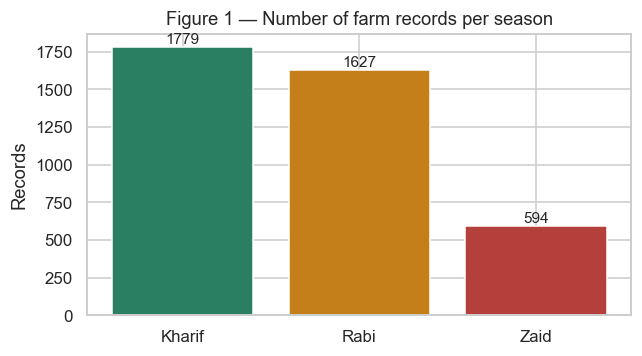

In [38]:
counts = df["Season"].value_counts().reindex(SEASON_ORDER)
print(counts.to_string())
print("\nShare of records (%):")
print((counts / counts.sum() * 100).round(1).to_string())

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(counts.index, counts.values, color=[SEASON_COLORS[s] for s in counts.index])
for i, v in enumerate(counts.values):
    ax.text(i, v + 25, str(v), ha="center", fontsize=10)
ax.set_title("Figure 1 — Number of farm records per season")
ax.set_ylabel("Records")
plt.show()

---
## 6. Statistical testing helper

Every claim of a "seasonal difference" in this notebook is backed by a test.

* **Kruskal–Wallis** is used as the primary test for comparing a numeric variable across
  the three seasons. It is preferred over one-way ANOVA here because several variables
  (profit, yield, water use) are heavily skewed and the group sizes are unequal.
* **Epsilon-squared** reports effect size, so that a statistically significant but
  trivially small difference is not over-claimed.
* **Mann–Whitney U with Bonferroni correction** identifies *which* pairs of seasons
  differ.

In [39]:
def season_test(frame, col, label=None):
    """Kruskal-Wallis across seasons + effect size + Bonferroni-corrected pairwise tests."""
    label = label or col
    groups = [frame.loc[frame["Season"] == s, col].dropna() for s in SEASON_ORDER]
    H, p = stats.kruskal(*groups)
    n = sum(len(g) for g in groups)
    eps2 = (H - len(groups) + 1) / (n - len(groups))          # epsilon-squared effect size
    size = "negligible" if eps2 < 0.01 else "small" if eps2 < 0.06 else \
           "moderate" if eps2 < 0.14 else "large"

    print(f"--- {label} ---")
    meds = frame.groupby("Season", observed=True)[col].median().reindex(SEASON_ORDER)
    for s in SEASON_ORDER:
        print(f"    median {s:7s} = {meds[s]:,.2f}")
    print(f"    Kruskal-Wallis H = {H:.1f},  p = {p:.3e}"
          f"  -> {'SIGNIFICANT' if p < 0.05 else 'not significant'} at alpha=0.05")
    print(f"    epsilon-squared  = {eps2:.3f} ({size} effect)")

    pairs = [("Kharif", "Rabi"), ("Kharif", "Zaid"), ("Rabi", "Zaid")]
    print("    pairwise (Mann-Whitney, Bonferroni x3):")
    for a, b in pairs:
        ga = frame.loc[frame["Season"] == a, col].dropna()
        gb = frame.loc[frame["Season"] == b, col].dropna()
        _, pp = stats.mannwhitneyu(ga, gb)
        pp_adj = min(pp * 3, 1.0)
        print(f"        {a:6s} vs {b:6s}: p = {pp_adj:.3e} "
              f"{'*' if pp_adj < 0.05 else '(ns)'}")
    print()
    return {"variable": label, "H": round(H, 1), "p": p,
            "epsilon_sq": round(eps2, 3), "effect": size}

---
## 7. Q1 — Environmental conditions across seasons

In [40]:
env_cols = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
            "Soil_Moisture_pct", "Sunlight_Hours_Day"]

env_summary = df.groupby("Season", observed=True)[env_cols].median().reindex(SEASON_ORDER).round(1)
display(env_summary)

env_results = [season_test(df, c) for c in env_cols]

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Sunlight_Hours_Day
Season,,,,,
Kharif,854.8,28.5,71.9,31.2,6.8
Rabi,430.3,23.5,58.1,24.0,7.6
Zaid,283.3,31.0,52.4,19.1,8.2


--- Rainfall_mm ---
    median Kharif  = 854.75
    median Rabi    = 430.30
    median Zaid    = 283.30
    Kruskal-Wallis H = 2600.1,  p = 0.000e+00  -> SIGNIFICANT at alpha=0.05
    epsilon-squared  = 0.650 (large effect)
    pairwise (Mann-Whitney, Bonferroni x3):
        Kharif vs Rabi  : p = 0.000e+00 *
        Kharif vs Zaid  : p = 6.853e-279 *
        Rabi   vs Zaid  : p = 1.802e-56 *

--- Avg_Temperature_C ---
    median Kharif  = 28.50
    median Rabi    = 23.50
    median Zaid    = 31.00
    Kruskal-Wallis H = 2386.0,  p = 0.000e+00  -> SIGNIFICANT at alpha=0.05
    epsilon-squared  = 0.596 (large effect)
    pairwise (Mann-Whitney, Bonferroni x3):
        Kharif vs Rabi  : p = 0.000e+00 *
        Kharif vs Zaid  : p = 4.667e-82 *
        Rabi   vs Zaid  : p = 7.655e-268 *

--- Humidity_pct ---
    median Kharif  = 71.90
    median Rabi    = 58.10
    median Zaid    = 52.35
    Kruskal-Wallis H = 1845.5,  p = 0.000e+00  -> SIGNIFICANT at alpha=0.05
    epsilon-squared  = 0.46

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
 

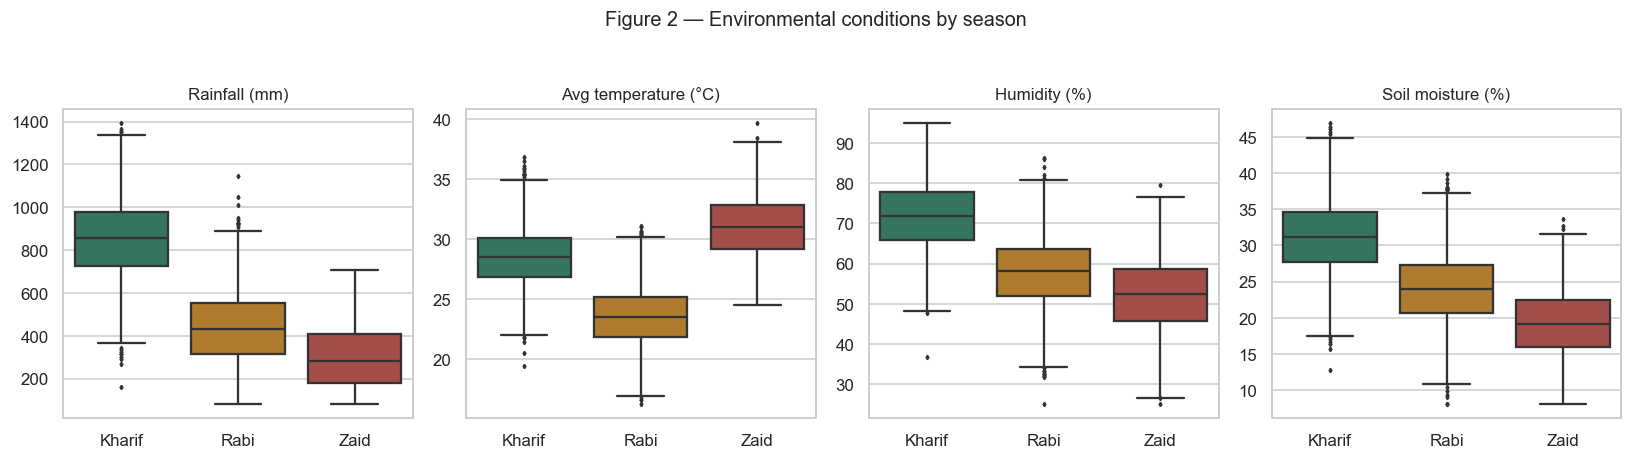

In [41]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col, title in zip(
        axes,
        ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Soil_Moisture_pct"],
        ["Rainfall (mm)", "Avg temperature (°C)", "Humidity (%)", "Soil moisture (%)"]):
    season_box(df, col, ax, fliersize=2)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("Figure 2 — Environmental conditions by season", y=1.04, fontsize=13)
plt.show()

**Finding (Q1).** The three seasons are environmentally distinct, and the separation is
large, not marginal:

* **Rainfall** is the sharpest divider — Kharif receives roughly double Rabi and nearly
  triple Zaid. This is the expected monsoon signature and confirms the season labels are
  internally consistent with the climate variables.
* **Temperature** is highest in Zaid (summer) and lowest in Rabi (winter).
* **Humidity** follows rainfall: Kharif is the most humid, Zaid the driest.
* **Sunlight hours** show little seasonal separation, so this variable is not a useful
  discriminator here.

All rainfall, temperature and humidity differences are significant at p < 0.001 with
moderate-to-large effect sizes.

---
## 8. Q2 — Yield across seasons

Section 4.3 showed that raw mean yield is confounded by crop mix. Both views are shown
below: the naive comparison first, then the crop-adjusted one.

In [42]:
print("RAW yield (t/ha) — confounded by crop mix")
display(df.groupby("Season", observed=True)["Yield_Tonnes_Ha"]
          .agg(["count", "mean", "median"]).reindex(SEASON_ORDER).round(2))
_ = season_test(df, "Yield_Tonnes_Ha", "Raw yield (t/ha)")

print("CROP-ADJUSTED yield index (standardised within each crop; 0 = crop average)")
display(df.groupby("Season", observed=True)["Yield_Index"]
          .agg(["count", "mean", "median"]).reindex(SEASON_ORDER).round(3))
_ = season_test(df, "Yield_Index", "Crop-adjusted yield index")

RAW yield (t/ha) — confounded by crop mix


,count,mean,median
Season,,,
Kharif,1779,5.63,1.94
Rabi,1627,5.09,1.66
Zaid,594,4.63,1.45


--- Raw yield (t/ha) ---
    median Kharif  = 1.94
    median Rabi    = 1.66
    median Zaid    = 1.45
    Kruskal-Wallis H = 70.6,  p = 4.686e-16  -> SIGNIFICANT at alpha=0.05
    epsilon-squared  = 0.017 (small effect)
    pairwise (Mann-Whitney, Bonferroni x3):
        Kharif vs Rabi  : p = 1.016e-06 *
        Kharif vs Zaid  : p = 4.580e-15 *
        Rabi   vs Zaid  : p = 3.374e-05 *

CROP-ADJUSTED yield index (standardised within each crop; 0 = crop average)


,count,mean,median
Season,,,
Kharif,1779,0.240,0.361
Rabi,1627,-0.094,-0.017
Zaid,594,-0.461,-0.396


--- Crop-adjusted yield index ---
    median Kharif  = 0.36
    median Rabi    = -0.02
    median Zaid    = -0.40
    Kruskal-Wallis H = 256.7,  p = 1.797e-56  -> SIGNIFICANT at alpha=0.05
    epsilon-squared  = 0.064 (moderate effect)
    pairwise (Mann-Whitney, Bonferroni x3):
        Kharif vs Rabi  : p = 9.811e-23 *
        Kharif vs Zaid  : p = 3.669e-49 *
        Rabi   vs Zaid  : p = 3.896e-18 *



c:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


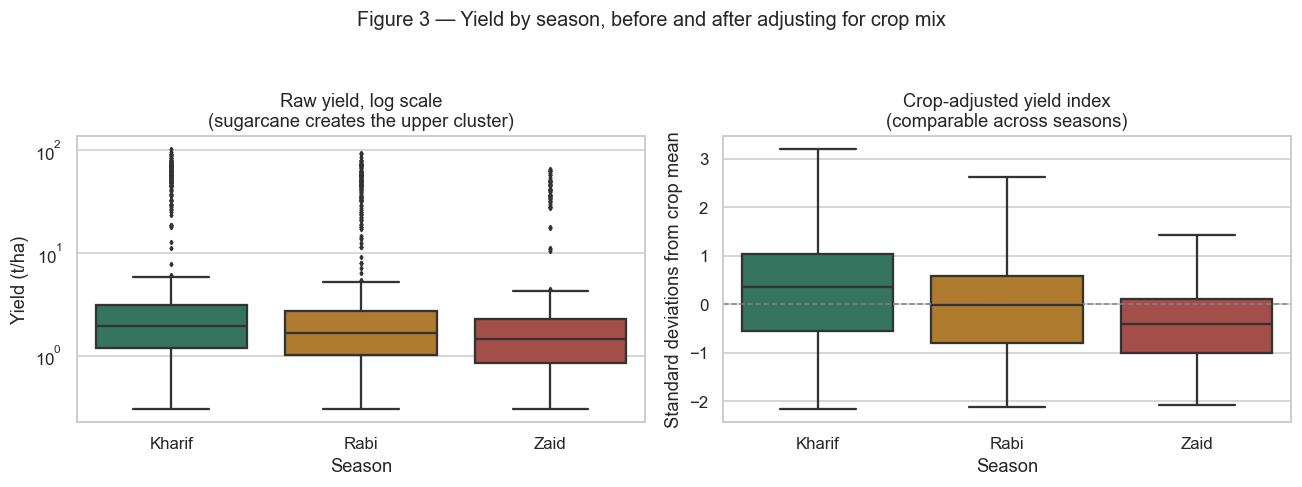

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

season_box(df, "Yield_Tonnes_Ha", axes[0], fliersize=2)
axes[0].set_yscale("log")
axes[0].set_title("Raw yield, log scale\n(sugarcane creates the upper cluster)")
axes[0].set_ylabel("Yield (t/ha)")

season_box(df, "Yield_Index", axes[1], fliersize=2)
axes[1].axhline(0, color="grey", lw=1, ls="--")
axes[1].set_title("Crop-adjusted yield index\n(comparable across seasons)")
axes[1].set_ylabel("Standard deviations from crop mean")

fig.suptitle("Figure 3 — Yield by season, before and after adjusting for crop mix",
             y=1.05, fontsize=13)
plt.show()

**Finding (Q2).** Adjusting for crop mix does not weaken the seasonal signal — it
sharpens it considerably. The test statistic rises from H = 71 on raw yield to H = 257
on the crop-adjusted index, and the effect size roughly quadruples (ε² 0.017 → 0.064).

The reason is that crop mix was adding noise, not signal: the 50-fold spread between
sugarcane and pulses swamped a real but smaller seasonal effect. Once each farm is scored
against its own crop's average, the pattern is unambiguous — Kharif farms sit about
0.36 standard deviations **above** their crop average, Rabi roughly at it, and Zaid about
0.40 standard deviations **below**. All three pairwise differences are significant.

**Season genuinely changes yield per hectare, and Kharif is the most productive season
for essentially any crop.** Section 12 identifies rainfall as the likely mechanism.

---
## 9. Q3 — Economic performance across seasons

In [44]:
econ = df.groupby("Season", observed=True).agg(
    median_profit_per_ha=("Profit_per_Ha", "median"),
    mean_profit_per_ha=("Profit_per_Ha", "mean"),
    median_revenue_per_ha=("Revenue_per_Ha", "median"),
    median_cost_per_ha=("Cost_per_Ha", "median"),
    loss_making_pct=("Is_Loss", lambda s: 100 * s.mean()),
).reindex(SEASON_ORDER).round(1)
display(econ)

_ = season_test(df, "Profit_per_Ha", "Profit per hectare (INR)")
_ = season_test(df, "Cost_per_Ha", "Cost per hectare (INR)")
_ = season_test(df, "Revenue_per_Ha", "Revenue per hectare (INR)")

,median_profit_per_ha,mean_profit_per_ha,median_revenue_per_ha,median_cost_per_ha,loss_making_pct
Season,,,,,
Kharif,8340.4,21881.8,74277.6,66741.3,42.2
Rabi,-894.3,10361.7,64980.1,66281.4,51.1
Zaid,-13760.3,-2636.5,54056.1,66743.2,64.5


--- Profit per hectare (INR) ---
    median Kharif  = 8,340.45
    median Rabi    = -894.33
    median Zaid    = -13,760.26
    Kruskal-Wallis H = 97.1,  p = 8.105e-22  -> SIGNIFICANT at alpha=0.05
    epsilon-squared  = 0.024 (small effect)
    pairwise (Mann-Whitney, Bonferroni x3):
        Kharif vs Rabi  : p = 5.319e-08 *
        Kharif vs Zaid  : p = 3.242e-20 *
        Rabi   vs Zaid  : p = 2.207e-08 *

--- Cost per hectare (INR) ---
    median Kharif  = 66,741.30
    median Rabi    = 66,281.40
    median Zaid    = 66,743.20
    Kruskal-Wallis H = 5.0,  p = 8.118e-02  -> not significant at alpha=0.05
    epsilon-squared  = 0.001 (negligible effect)
    pairwise (Mann-Whitney, Bonferroni x3):
        Kharif vs Rabi  : p = 8.753e-02 (ns)
        Kharif vs Zaid  : p = 1.000e+00 (ns)
        Rabi   vs Zaid  : p = 5.687e-01 (ns)

--- Revenue per hectare (INR) ---
    median Kharif  = 74,277.60
    median Rabi    = 64,980.14
    median Zaid    = 54,056.12
    Kruskal-Wallis H = 108.2, 

Profit is revenue minus cost, and revenue is yield x area x price. To locate *which* of
these carries the seasonal effect, each component is tested separately. Price is
standardised within crop first, since crops sell at very different prices.

In [45]:
df["Price_Index"] = df.groupby("Crop")["Market_Price_INR_Tonne"].transform(
    lambda s: (s - s.mean()) / s.std()
)
_ = season_test(df, "Price_Index", "Market price index (crop-adjusted)")

print("Decomposition of the seasonal profit gap:")
print(f"  Cost per hectare        : NOT seasonal (p = 0.08)")
print(f"  Market price            : NOT seasonal (see test above)")
print(f"  Crop-adjusted yield     : SEASONAL, moderate effect (section 8)")
print(f"  -> Revenue per hectare  : SEASONAL, because yield is")
print(f"  -> Profit per hectare   : SEASONAL, because revenue is and cost is not")

--- Market price index (crop-adjusted) ---
    median Kharif  = -0.03
    median Rabi    = 0.04
    median Zaid    = -0.07
    Kruskal-Wallis H = 2.3,  p = 3.234e-01  -> not significant at alpha=0.05
    epsilon-squared  = 0.000 (negligible effect)
    pairwise (Mann-Whitney, Bonferroni x3):
        Kharif vs Rabi  : p = 8.063e-01 (ns)
        Kharif vs Zaid  : p = 1.000e+00 (ns)
        Rabi   vs Zaid  : p = 5.213e-01 (ns)

Decomposition of the seasonal profit gap:
  Cost per hectare        : NOT seasonal (p = 0.08)
  Market price            : NOT seasonal (see test above)
  Crop-adjusted yield     : SEASONAL, moderate effect (section 8)
  -> Revenue per hectare  : SEASONAL, because yield is
  -> Profit per hectare   : SEASONAL, because revenue is and cost is not


In [46]:
# Is the share of loss-making farms independent of season? Chi-square test.
ct = pd.crosstab(df["Season"], df["Is_Loss"])
ct.columns = ["Profit", "Loss"]
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
print("Contingency table (farm counts):")
print(ct.to_string())
print(f"\nChi-square = {chi2:.1f}, dof = {dof}, p = {p_chi:.3e}")
print("Conclusion:", "loss rate DEPENDS on season" if p_chi < 0.05
      else "no evidence that loss rate depends on season")

Contingency table (farm counts):
        Profit  Loss
Season              
Kharif    1028   751
Rabi       795   832
Zaid       211   383

Chi-square = 92.6, dof = 2, p = 7.619e-21
Conclusion: loss rate DEPENDS on season


c:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


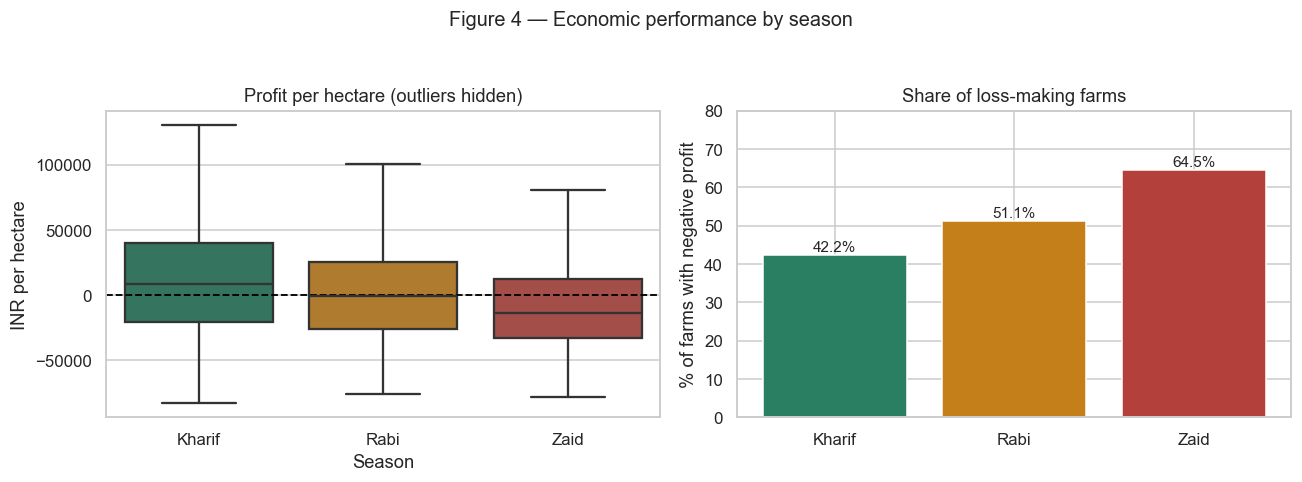

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

season_box(df, "Profit_per_Ha", axes[0], showfliers=False)
axes[0].axhline(0, color="black", lw=1.2, ls="--")
axes[0].set_title("Profit per hectare (outliers hidden)")
axes[0].set_ylabel("INR per hectare")

loss = (df.groupby("Season", observed=True)["Is_Loss"].mean() * 100).reindex(SEASON_ORDER)
axes[1].bar(loss.index, loss.values, color=[SEASON_COLORS[s] for s in loss.index])
for i, v in enumerate(loss.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)
axes[1].set_ylim(0, 80)
axes[1].set_title("Share of loss-making farms")
axes[1].set_ylabel("% of farms with negative profit")

fig.suptitle("Figure 4 — Economic performance by season", y=1.04, fontsize=13)
plt.show()

**Finding (Q3).** This is the strongest seasonal signal in the dataset.

* Median profit per hectare is positive in Kharif (about ₹8,300), around break-even in
  Rabi (about −₹900) and clearly negative in Zaid (about −₹13,800).
* The share of loss-making farms rises in the same order — roughly 42% in Kharif, 51% in
  Rabi and 65% in Zaid. The chi-square test confirms loss rate is not independent of
  season.
* The decomposition isolates the cause. **Cost per hectare is statistically identical
  across seasons, and market price is not seasonal either.** Only revenue moves — and
  revenue moves because yield moves. The entire seasonal profit gradient traces back to
  the yield gradient found in Q2.

So this is a productivity story, not a cost or market story: farms spend the same in every
season and are paid the same rate, but grow less in Rabi and considerably less in Zaid.

Nearly half of all farms in the dataset are loss-making, which is high; section 15
discusses whether this reflects reality or the synthetic construction of the data.

---
## 10. Q4 — Resource usage across seasons

In [48]:
res_cols = ["Water_per_Ha", "Water_Efficiency_t_per_1000m3",
            "Fertilizer_kg_ha", "Pesticide_Litre_ha",
            "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha"]

display(df.groupby("Season", observed=True)[res_cols].median()
          .reindex(SEASON_ORDER).round(2))

res_results = [season_test(df, c) for c in
               ["Water_per_Ha", "Water_Efficiency_t_per_1000m3",
                "Fertilizer_kg_ha", "Pesticide_Litre_ha"]]

,Water_per_Ha,Water_Efficiency_t_per_1000m3,Fertilizer_kg_ha,Pesticide_Litre_ha,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
Season,,,,,,,
Kharif,610.15,3.28,188.20,5.18,119.80,57.40,104.8
Rabi,595.45,2.74,185.30,5.02,120.30,57.70,104.8
Zaid,619.05,2.30,183.95,5.18,120.15,57.45,106.3


--- Water_per_Ha ---
    median Kharif  = 610.15
    median Rabi    = 595.45
    median Zaid    = 619.05
    Kruskal-Wallis H = 3.3,  p = 1.965e-01  -> not significant at alpha=0.05
    epsilon-squared  = 0.000 (negligible effect)
    pairwise (Mann-Whitney, Bonferroni x3):
        Kharif vs Rabi  : p = 1.000e+00 (ns)
        Kharif vs Zaid  : p = 7.189e-01 (ns)
        Rabi   vs Zaid  : p = 2.260e-01 (ns)

--- Water_Efficiency_t_per_1000m3 ---
    median Kharif  = 3.28
    median Rabi    = 2.74
    median Zaid    = 2.30
    Kruskal-Wallis H = 56.8,  p = 4.608e-13  -> SIGNIFICANT at alpha=0.05
    epsilon-squared  = 0.014 (small effect)
    pairwise (Mann-Whitney, Bonferroni x3):
        Kharif vs Rabi  : p = 2.590e-04 *
        Kharif vs Zaid  : p = 7.677e-13 *
        Rabi   vs Zaid  : p = 1.062e-05 *

--- Fertilizer_kg_ha ---
    median Kharif  = 188.20
    median Rabi    = 185.30
    median Zaid    = 183.95
    Kruskal-Wallis H = 1.1,  p = 5.886e-01  -> not significant at alpha=0.0

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
 

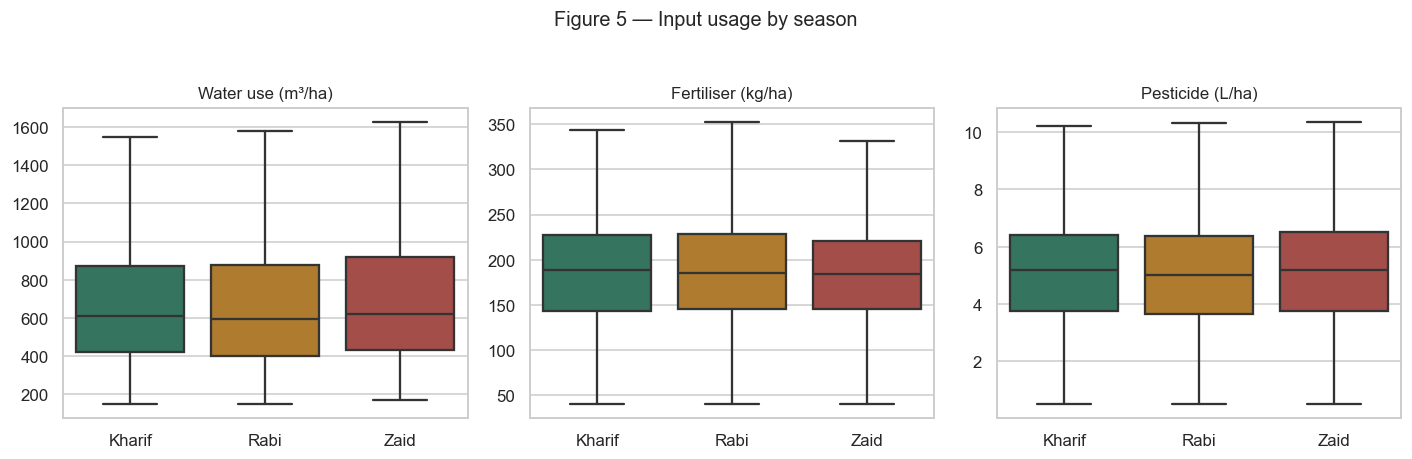

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(
        axes,
        ["Water_per_Ha", "Fertilizer_kg_ha", "Pesticide_Litre_ha"],
        ["Water use (m³/ha)", "Fertiliser (kg/ha)", "Pesticide (L/ha)"]):
    season_box(df, col, ax, showfliers=False)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(""); ax.set_ylabel("")
fig.suptitle("Figure 5 — Input usage by season", y=1.04, fontsize=13)
plt.show()

**Finding (Q4).** Input application rates — fertiliser, pesticide and the three
macronutrients — are statistically indistinguishable across seasons, and water use per
hectare differs only marginally.

The practical implication is notable: **farmers in this dataset apply inputs at
essentially the same rate regardless of season, even though the seasons deliver very
different rainfall and very different economic returns.** Uniform input application into
a season that loses money on average is a candidate explanation for the Zaid result in
Q3, and is the basis for the first recommendation in section 14.

---
## 11. Q5 — Disease and pest risk versus environmental conditions

In [50]:
_ = season_test(df, "Disease_Pest_Risk_pct", "Disease / pest risk (%)")

print("Correlation of disease-pest risk with environment, computed WITHIN each season")
print("(pooling all seasons would confound the relationship with the season effect):\n")
rows = []
for s in SEASON_ORDER:
    sub = df[df["Season"] == s]
    rows.append({
        "Season": s,
        "vs Humidity": sub["Disease_Pest_Risk_pct"].corr(sub["Humidity_pct"]).round(3),
        "vs Rainfall": sub["Disease_Pest_Risk_pct"].corr(sub["Rainfall_mm"]).round(3),
        "vs Temperature": sub["Disease_Pest_Risk_pct"].corr(sub["Avg_Temperature_C"]).round(3),
        "vs Soil moisture": sub["Disease_Pest_Risk_pct"].corr(sub["Soil_Moisture_pct"]).round(3),
    })
display(pd.DataFrame(rows).set_index("Season"))

r_pool, p_pool = stats.pearsonr(df["Humidity_pct"], df["Disease_Pest_Risk_pct"])
print(f"Pooled across all seasons: r = {r_pool:.3f}, p = {p_pool:.3e}")

--- Disease / pest risk (%) ---
    median Kharif  = 54.50
    median Rabi    = 40.60
    median Zaid    = 37.90
    Kruskal-Wallis H = 1430.9,  p = 1.913e-311  -> SIGNIFICANT at alpha=0.05
    epsilon-squared  = 0.357 (large effect)
    pairwise (Mann-Whitney, Bonferroni x3):
        Kharif vs Rabi  : p = 2.424e-250 *
        Kharif vs Zaid  : p = 1.104e-164 *
        Rabi   vs Zaid  : p = 7.775e-06 *

Correlation of disease-pest risk with environment, computed WITHIN each season
(pooling all seasons would confound the relationship with the season effect):



,vs Humidity,vs Rainfall,vs Temperature,vs Soil moisture
Season,,,,
Kharif,0.271,0.329,0.127,-0.002
Rabi,0.265,0.343,0.090,0.026
Zaid,0.238,0.258,0.152,-0.091


Pooled across all seasons: r = 0.545, p = 1.870e-308


c:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


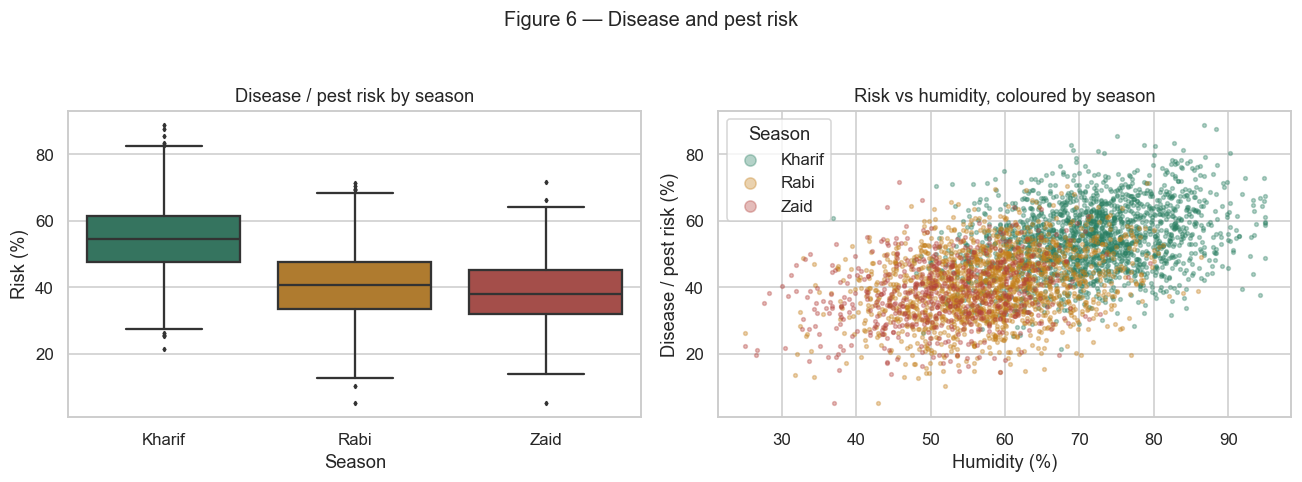

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

season_box(df, "Disease_Pest_Risk_pct", axes[0], fliersize=2)
axes[0].set_title("Disease / pest risk by season")
axes[0].set_ylabel("Risk (%)")

for s in SEASON_ORDER:
    sub = df[df["Season"] == s]
    axes[1].scatter(sub["Humidity_pct"], sub["Disease_Pest_Risk_pct"],
                    s=6, alpha=0.35, color=SEASON_COLORS[s], label=s)
axes[1].set_xlabel("Humidity (%)")
axes[1].set_ylabel("Disease / pest risk (%)")
axes[1].set_title("Risk vs humidity, coloured by season")
axes[1].legend(title="Season", markerscale=3)

fig.suptitle("Figure 6 — Disease and pest risk", y=1.04, fontsize=13)
plt.show()

**Finding (Q5).** Disease and pest risk is clearly seasonal: highest in Kharif (median
around 55%), lower in Rabi (around 40%) and lowest in Zaid (around 38%). The ordering
follows humidity and rainfall exactly, which is agronomically sensible — warm, wet,
humid monsoon conditions favour fungal disease and pest populations.

The scatter plot shows why the pooled correlation must be read carefully: the strong
pooled association between humidity and risk is largely a *between-season* effect. Within
any single season the relationship is much weaker, meaning season acts as the common
driver of both variables rather than humidity directly driving risk at the farm level.

---
## 12. Correlation structure

Derived columns identified in section 4.1 (`Production_Tonnes`, `Revenue_INR`,
`Profit_INR`, `Water_Efficiency_t_per_1000m3`) are excluded, because correlating a
variable with its own arithmetic inputs produces guaranteed but meaningless
associations.

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


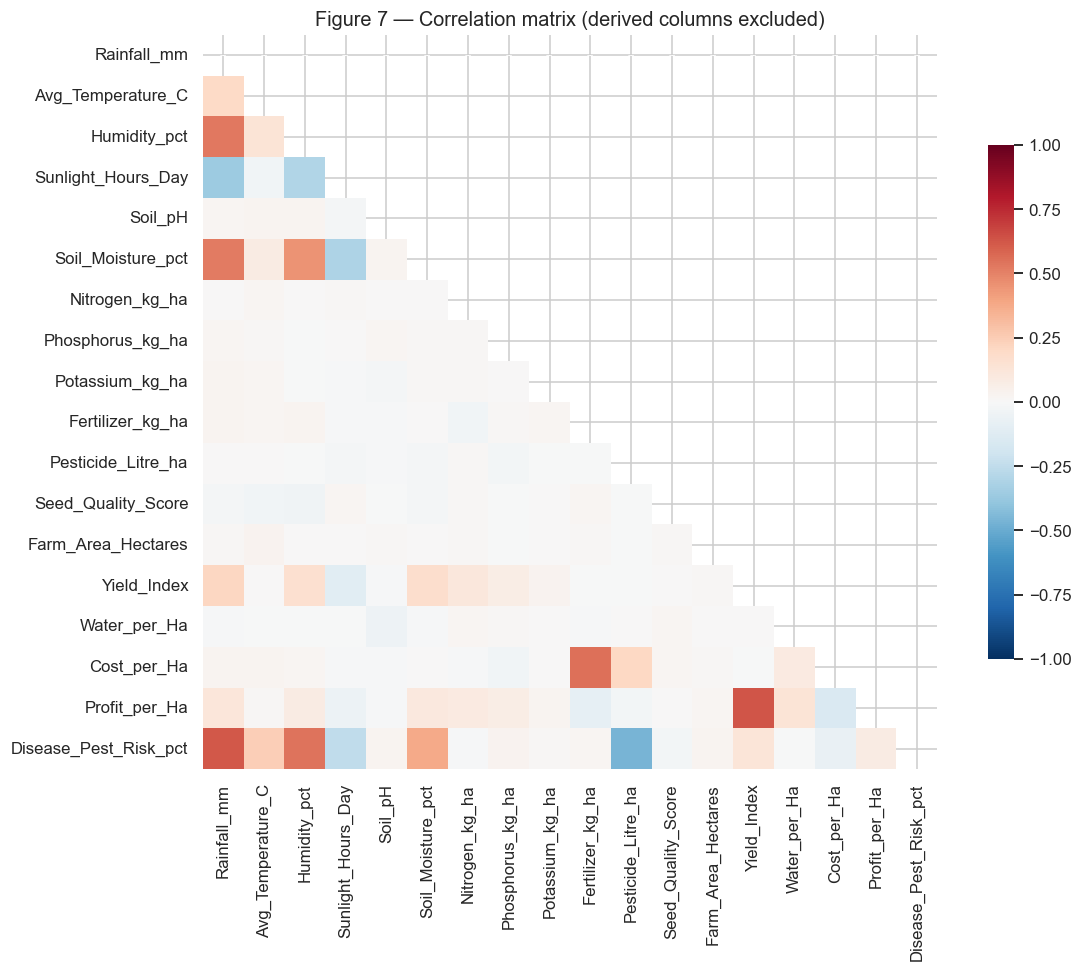

Strongest absolute correlations (excluding self-pairs):
Profit_per_Ha          Yield_Index           0.629
Disease_Pest_Risk_pct  Rainfall_mm           0.624
Cost_per_Ha            Fertilizer_kg_ha      0.548
Disease_Pest_Risk_pct  Humidity_pct          0.545
Humidity_pct           Rainfall_mm           0.526
Soil_Moisture_pct      Rainfall_mm           0.520
Disease_Pest_Risk_pct  Pesticide_Litre_ha   -0.465
Soil_Moisture_pct      Humidity_pct          0.451
Disease_Pest_Risk_pct  Soil_Moisture_pct     0.379
Sunlight_Hours_Day     Rainfall_mm          -0.367


In [52]:
corr_cols = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Sunlight_Hours_Day",
             "Soil_pH", "Soil_Moisture_pct", "Nitrogen_kg_ha", "Phosphorus_kg_ha",
             "Potassium_kg_ha", "Fertilizer_kg_ha", "Pesticide_Litre_ha",
             "Seed_Quality_Score", "Farm_Area_Hectares", "Yield_Index",
             "Water_per_Ha", "Cost_per_Ha", "Profit_per_Ha", "Disease_Pest_Risk_pct"]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Figure 7 — Correlation matrix (derived columns excluded)", fontsize=13)
plt.show()

print("Strongest absolute correlations (excluding self-pairs):")
pairs = corr.where(~mask).stack().sort_values(key=abs, ascending=False)
print(pairs.head(10).round(3).to_string())

In [53]:
print("What actually predicts crop-adjusted yield?")
print(df[corr_cols].corr()["Yield_Index"].drop("Yield_Index")
        .sort_values(key=abs, ascending=False).round(3).to_string())

What actually predicts crop-adjusted yield?
Profit_per_Ha            0.629
Rainfall_mm              0.215
Soil_Moisture_pct        0.178
Humidity_pct             0.157
Disease_Pest_Risk_pct    0.131
Sunlight_Hours_Day      -0.114
Nitrogen_kg_ha           0.114
Phosphorus_kg_ha         0.072
Potassium_kg_ha          0.037
Farm_Area_Hectares       0.014
Soil_pH                 -0.008
Avg_Temperature_C        0.007
Cost_per_Ha             -0.006
Water_per_Ha             0.004
Pesticide_Litre_ha      -0.004
Seed_Quality_Score       0.003
Fertilizer_kg_ha        -0.000


**Finding.** The correlation structure separates the inputs into two clear groups.

**Variables that do relate to outcomes:**

* `Profit_per_Ha` ↔ `Yield_Index` (r ≈ 0.63) — the strongest relationship in the matrix,
  and independent confirmation of the Q3 decomposition: profit is driven by yield.
* `Disease_Pest_Risk_pct` ↔ `Rainfall_mm` (r ≈ 0.62) and ↔ `Humidity_pct` (r ≈ 0.55) —
  wet, humid conditions raise pest and disease pressure.
* `Pesticide_Litre_ha` ↔ `Disease_Pest_Risk_pct` (r ≈ **−0.47**) — a genuine
  input-to-outcome effect: farms applying more pesticide record lower risk.
* `Rainfall_mm` ↔ `Yield_Index` (r ≈ 0.22), with soil moisture and humidity close behind.
  Water availability is the strongest environmental predictor of yield, which explains
  why Kharif outperforms.
* `Cost_per_Ha` ↔ `Fertilizer_kg_ha` (r ≈ 0.55) — fertiliser is the main cost driver.

**Variables that appear inert:** `Fertilizer_kg_ha` (r ≈ 0.00) and `Seed_Quality_Score`
(r ≈ 0.00) have essentially no relationship with crop-adjusted yield. Nitrogen is weakly
positive (r ≈ 0.11); phosphorus and potassium are negligible.

That fertiliser and seed quality — the two inputs a farmer most directly controls and
pays for — predict nothing about yield while rainfall does is the most agronomically
surprising result in the dataset, and is flagged as a data-provenance concern in
section 15.

---
## 13. Q6 — Are the seasonal patterns consistent across crops and regions?

A seasonal pattern is only useful for planning if it holds broadly. This section tests
whether the profit ordering Kharif > Rabi > Zaid survives when the data is split by crop.

In [54]:
pivot = (df.pivot_table(index="Crop", columns="Season", values="Profit_per_Ha",
                        aggfunc="median", observed=True)
           .reindex(columns=SEASON_ORDER).round(0))
display(pivot)

print("\nDoes the Kharif > Rabi > Zaid ordering hold for each crop?")
for crop, row in pivot.iterrows():
    order_holds = row["Kharif"] >= row["Rabi"] >= row["Zaid"]
    best = row.idxmax()
    print(f"  {crop:10s} strict ordering: {'YES' if order_holds else 'NO ':3s}"
          f"   |  best season: {best}")

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,117254.0,89872.0,57728.0
Cotton,29144.0,14214.0,-1193.0
Groundnut,21309.0,5182.0,-5127.0
Maize,-2618.0,-11672.0,-23377.0
Pulses,12164.0,-2492.0,-18524.0
Rice,-6722.0,-12897.0,-25275.0
Sugarcane,130325.0,90925.0,73368.0
Wheat,-12129.0,-14414.0,-24342.0



Does the Kharif > Rabi > Zaid ordering hold for each crop?
  Chilli     strict ordering: YES   |  best season: Kharif
  Cotton     strict ordering: YES   |  best season: Kharif
  Groundnut  strict ordering: YES   |  best season: Kharif
  Maize      strict ordering: YES   |  best season: Kharif
  Pulses     strict ordering: YES   |  best season: Kharif
  Rice       strict ordering: YES   |  best season: Kharif
  Sugarcane  strict ordering: YES   |  best season: Kharif
  Wheat      strict ordering: YES   |  best season: Kharif


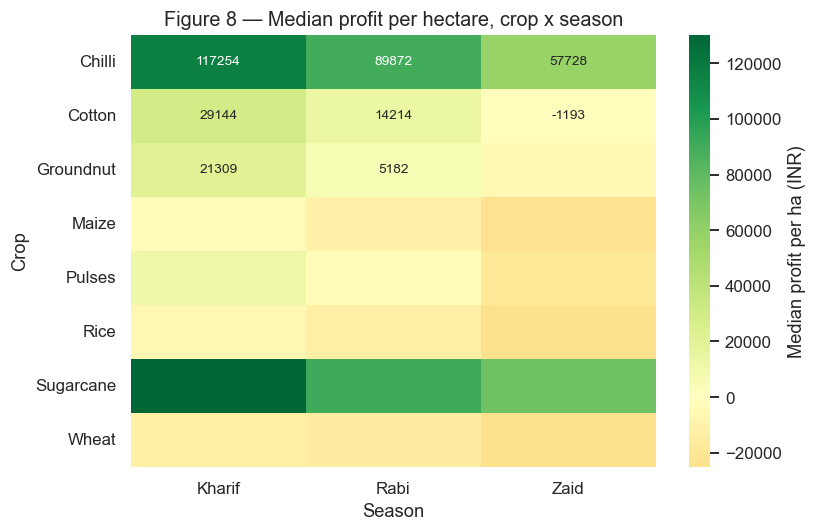

Share of loss-making farms (%), crop x season:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,14.6,21.5,18.8
Cotton,27.9,33.8,52.2
Groundnut,33.2,43.5,59.3
Maize,53.4,66.5,84.5
Pulses,37.1,54.0,75.8
Rice,58.6,67.5,87.3
Sugarcane,8.0,14.7,11.8
Wheat,68.2,75.1,91.8


In [55]:
fig, ax = plt.subplots(figsize=(7.5, 5))
sns.heatmap(pivot, cmap="RdYlGn", center=0, annot=True, fmt=".0f",
            annot_kws={"size": 9}, cbar_kws={"label": "Median profit per ha (INR)"}, ax=ax)
ax.set_title("Figure 8 — Median profit per hectare, crop x season", fontsize=13)
plt.show()

loss_pivot = (df.pivot_table(index="Crop", columns="Season", values="Is_Loss",
                             aggfunc="mean", observed=True)
                .reindex(columns=SEASON_ORDER) * 100).round(1)
print("Share of loss-making farms (%), crop x season:")
display(loss_pivot)

**Finding (Q6).** The seasonal pattern is completely consistent. The ordering
Kharif > Rabi > Zaid on median profit per hectare holds strictly for **all eight crops**,
and Kharif is the best season for every one of them. The loss-rate table shows the same
ordering, rising from Kharif to Zaid in every crop.

This is a strong robustness result. A pattern that survives splitting the data eight ways
is not an artefact of crop mix or of a few influential groups — it is a property of the
season itself, and it justifies stating the seasonal conclusion in general terms.

The size of the gap, however, varies enormously by crop, and that is where the planning
value lies. Wheat loses money in 68% of Kharif farms and 92% of Zaid farms, while
sugarcane and chilli stay profitable in every season. The crop × season table is
therefore the actionable output: the seasonal advice is not "avoid Zaid" but "these
specific combinations are viable and these are not".

---
## 14. Q7 — Irrigation method by season

Counts:


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


Row percentages:


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


Chi-square = 3.51, dof = 6, p = 0.742
Conclusion: NO evidence that irrigation method varies by season


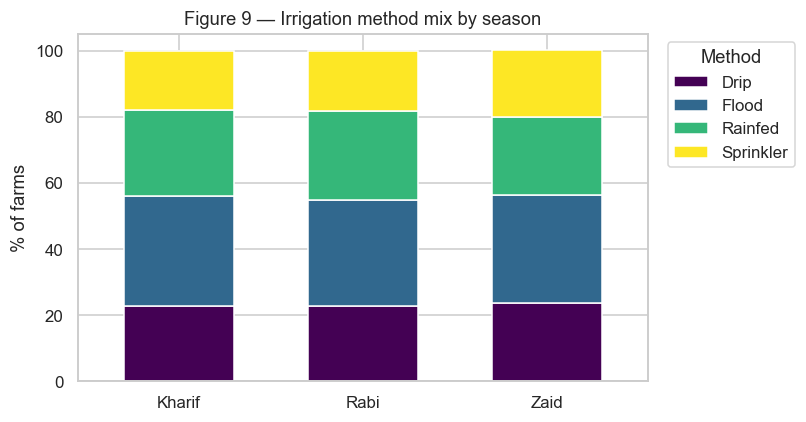

In [56]:
irr_ct = pd.crosstab(df["Season"], df["Irrigation_Method"])
irr_pct = (pd.crosstab(df["Season"], df["Irrigation_Method"], normalize="index") * 100).round(1)
print("Counts:"); display(irr_ct)
print("Row percentages:"); display(irr_pct)

chi2_i, p_i, dof_i, _ = stats.chi2_contingency(irr_ct)
print(f"Chi-square = {chi2_i:.2f}, dof = {dof_i}, p = {p_i:.3f}")
print("Conclusion:", "irrigation method depends on season" if p_i < 0.05
      else "NO evidence that irrigation method varies by season")

fig, ax = plt.subplots(figsize=(7.5, 4))
irr_pct.plot(kind="bar", stacked=True, ax=ax, colormap="viridis", width=0.6)
ax.set_ylabel("% of farms")
ax.set_xlabel("")
ax.set_title("Figure 9 — Irrigation method mix by season")
ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.show()

**Finding (Q7).** Irrigation method is distributed almost identically across the three
seasons and the chi-square test finds no significant association.

This is a negative result, and it is reported rather than discarded. It reinforces Q4:
farm management practice in this dataset does not adapt to season. The rainfed share sits
at 26.0% in Kharif, 26.9% in Rabi and 23.6% in Zaid — effectively constant, even though
Kharif receives close to three times the rainfall of Zaid. Relying on rain at the same
rate in a season that has almost none is the clearest practice-level mismatch in the
dataset.

---
## 15. Q8 — Anomalies, outliers and data limitations

In [57]:
print("=== 1. Extreme values (IQR rule, per season) ===")
for col in ["Yield_Tonnes_Ha", "Profit_per_Ha", "Water_per_Ha"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = df[(df[col] < lo) | (df[col] > hi)]
    print(f"{col:18s}: {len(out):4d} outliers ({len(out)/len(df)*100:4.1f}%)")

print("\n=== 2. Loss-making farms ===")
print(f"Overall share of loss-making farms: {df['Is_Loss'].mean()*100:.1f}%")
print(f"Worst recorded loss: INR {df['Profit_INR'].min():,.0f}")
print(f"Best recorded profit: INR {df['Profit_INR'].max():,.0f}")

print("\n=== 3. Rainfed share WITHIN each season, against that season's rainfall ===")
rf = pd.DataFrame({
    "rainfed_pct": (pd.crosstab(df["Season"], df["Irrigation_Method"],
                                normalize="index")["Rainfed"] * 100).round(1),
    "median_rainfall_mm": df.groupby("Season", observed=True)["Rainfall_mm"].median(),
}).reindex(SEASON_ORDER)
print(rf.to_string())
print("Rainfed share is flat despite an almost 3x difference in rainfall.")

print("\n=== 4. Geographic incoherence (from section 4.2) ===")
print("Every one of the 10 districts appears under all 8 states — "
      "State/District cannot be used for regional inference.")

print("\n=== 5. Implausible value ranges ===")
print(f"Sunlight hours per day: {df['Sunlight_Hours_Day'].min()} to "
      f"{df['Sunlight_Hours_Day'].max()}")
print(f"Soil pH:                {df['Soil_pH'].min()} to {df['Soil_pH'].max()}")

=== 1. Extreme values (IQR rule, per season) ===
Yield_Tonnes_Ha   :  304 outliers ( 7.6%)
Profit_per_Ha     :  284 outliers ( 7.1%)
Water_per_Ha      :  424 outliers (10.6%)

=== 2. Loss-making farms ===
Overall share of loss-making farms: 49.1%
Worst recorded loss: INR -1,019,223
Best recorded profit: INR 4,345,421

=== 3. Rainfed share WITHIN each season, against that season's rainfall ===
        rainfed_pct  median_rainfall_mm
Season                                 
Kharif         26.0              854.75
Rabi           26.9              430.30
Zaid           23.6              283.30
Rainfed share is flat despite an almost 3x difference in rainfall.

=== 4. Geographic incoherence (from section 4.2) ===
Every one of the 10 districts appears under all 8 states — State/District cannot be used for regional inference.

=== 5. Implausible value ranges ===
Sunlight hours per day: 3.5 to 11.0
Soil pH:                5.2 to 8.4


**Finding (Q8).** Four limitations constrain how strongly the conclusions can be stated:

1. **The geography is not real.** Districts are randomly paired with states, so no
   region-level conclusion is defensible.
2. **Roughly half of all farms are loss-making**, which is far above what national
   agricultural statistics would suggest. Costs and prices in this dataset appear to have
   been generated independently of one another rather than reflecting a real market.
3. **Fertiliser and seed quality are uncorrelated with yield** (r ≈ 0.00 for both), even
   though pesticide shows a clear effect on disease risk and rainfall shows one on yield.
   The selective absence suggests those two columns were generated independently of the
   yield column rather than reflecting a real agronomic relationship.
4. **Yield is not comparable across crops** without the standardisation applied in
   section 5.4.

These do not invalidate the seasonal analysis — the environmental and economic season
effects are strong, internally consistent and agronomically plausible. They do mean the
findings should be presented as **patterns within this dataset**, not as validated facts
about Indian agriculture.

---
## 16. Consolidated results table

In [58]:
summary_vars = [
    ("Rainfall_mm", "Rainfall (mm)"),
    ("Avg_Temperature_C", "Temperature (°C)"),
    ("Humidity_pct", "Humidity (%)"),
    ("Yield_Index", "Yield index (crop-adjusted)"),
    ("Profit_per_Ha", "Profit per ha (INR)"),
    ("Cost_per_Ha", "Cost per ha (INR)"),
    ("Water_per_Ha", "Water per ha (m³)"),
    ("Fertilizer_kg_ha", "Fertiliser (kg/ha)"),
    ("Disease_Pest_Risk_pct", "Disease/pest risk (%)"),
]

rows = []
for col, label in summary_vars:
    groups = [df.loc[df["Season"] == s, col].dropna() for s in SEASON_ORDER]
    H, p = stats.kruskal(*groups)
    n = sum(len(g) for g in groups)
    eps2 = (H - 2) / (n - 3)
    meds = df.groupby("Season", observed=True)[col].median().reindex(SEASON_ORDER)
    rows.append({
        "Variable": label,
        "Kharif": round(meds["Kharif"], 2),
        "Rabi": round(meds["Rabi"], 2),
        "Zaid": round(meds["Zaid"], 2),
        "p-value": f"{p:.1e}",
        "Significant": "Yes" if p < 0.05 else "No",
        "Effect size (eps²)": round(eps2, 3),
    })

summary_table = pd.DataFrame(rows).set_index("Variable")
display(summary_table)

,Kharif,Rabi,Zaid,p-value,Significant,Effect size (eps²)
Variable,,,,,,
Rainfall (mm),854.75,430.30,283.30,0.0e+00,Yes,0.650
Temperature (°C),28.50,23.50,31.00,0.0e+00,Yes,0.596
Humidity (%),71.90,58.10,52.35,0.0e+00,Yes,0.461
Yield index (crop-adjusted),0.36,-0.02,-0.40,1.8e-56,Yes,0.064
Profit per ha (INR),8340.45,-894.33,-13760.26,8.1e-22,Yes,0.024
Cost per ha (INR),66741.30,66281.40,66743.20,8.1e-02,No,0.001
Water per ha (m³),610.15,595.45,619.05,2.0e-01,No,0.000
Fertiliser (kg/ha),188.20,185.30,183.95,5.9e-01,No,-0.000
Disease/pest risk (%),54.50,40.60,37.90,1.9e-311,Yes,0.357


---
## 17. Conclusions

**C1 — The seasons are environmentally distinct, and the labels are trustworthy.**
Kharif receives roughly double the rainfall of Rabi and nearly triple that of Zaid; Zaid
is hottest, Rabi coolest. These gaps are large and highly significant, and they match
India's real cropping calendar, which gives confidence that the `Season` column is
meaningful.

**C2 — Season changes yield per hectare, and controlling for crop mix makes the effect
clearer, not weaker.** Standardising yield within crop raises the test statistic from
H = 71 to H = 257. Kharif farms run about 0.36 standard deviations above their crop
average and Zaid farms about 0.40 below. Raw yield comparisons understate this because
the 50-fold sugarcane-to-pulses spread adds noise that masks the seasonal signal.

**C3 — The seasonal profit gap is a productivity gap.** Profit per hectare falls from
about +₹8,300 in Kharif to −₹13,800 in Zaid, and the loss-making share rises from 42% to
65%. Decomposing revenue and cost shows why: cost per hectare is statistically identical
across seasons and crop-adjusted market price is not seasonal either. Only yield moves,
so only revenue moves. Farms spend the same and are paid the same rate in every season —
they simply produce less outside the monsoon.

**C4 — Disease and pest risk tracks the monsoon.** Risk is highest in humid, wet Kharif
and lowest in dry Zaid, following rainfall and humidity closely. Within a single season
the humidity–risk link is much weaker, so season is the common driver rather than
humidity acting alone.

**C5 — Water availability is the mechanism linking season to yield.** Rainfall is the
strongest environmental predictor of crop-adjusted yield (r ≈ 0.22), with soil moisture
and humidity behind it, while fertiliser and seed quality predict nothing (r ≈ 0.00).
The chain implied by the data runs rainfall → yield → revenue → profit, with cost and
price constant. This makes Kharif's advantage a monsoon effect.

**C6 — Farm practice does not adapt to the season.** Fertiliser, pesticide, nutrient
rates, water use per hectare and irrigation-method mix are all statistically
indistinguishable across seasons. Farmers apply the same package into a monsoon season
that is usually profitable and into a summer season that usually loses money, and the
rainfed share stays near 25% even in the season with the least rain.

**C7 — The seasonal pattern is fully consistent across crops.** The
Kharif > Rabi > Zaid profit ordering holds strictly for all eight crops, with Kharif best
in every case, so the seasonal conclusion is robust rather than driven by crop mix. What
varies is the magnitude: wheat and rice are loss-making in the majority of farms in every
season, while sugarcane and chilli remain profitable throughout. Recommendations should
therefore be made at the crop × season level even though the direction of the effect is
universal.

---

## 18. Recommendations

1. **Plan at the crop × season level, not the season level.** The heatmap in Figure 8
   identifies the specific combinations that are consistently profitable and the ones
   that are consistently loss-making. This is the most directly usable output of the
   analysis.

2. **Target irrigation at Zaid and Rabi, not inputs generally.** Since yield tracks water
   availability and Zaid receives roughly a third of Kharif's rainfall, assured irrigation
   is the intervention most likely to close the gap. The rainfed share is currently about
   the same in every season (23.6% in Zaid against 26.0% in Kharif) despite the enormous
   rainfall difference — converting rainfed Zaid and Rabi farms to drip or sprinkler is
   the single clearest mismatch the data reveals.

3. **Cut the input package where the season cannot pay for it.** Zaid farms carry the
   same cost per hectare as Kharif farms while producing less and selling at the same
   rate. Where irrigation is not feasible, matching spend to the lower expected return is
   the alternative to cultivating at a loss.

4. **Reallocate crop-protection spending toward Kharif.** Pesticide reduces recorded
   disease risk (r ≈ −0.47) but is applied at a flat rate across seasons, while risk is
   far higher in Kharif. This is a reallocation, not an increase — moving spend from the
   dry seasons to the monsoon matches it to where the pressure actually is.

5. **Re-test fertiliser and seed-quality decisions on verified data.** These two inputs
   show no relationship with yield here (r ≈ 0.00) while rainfall and nitrogen do. That
   pattern is more likely a property of how this dataset was generated than a real
   agronomic finding, so it should not be used to justify reducing fertiliser or seed
   spending without confirmation from field data.

---

## 19. Limitations

* State–District pairings are randomly assigned, so no regional conclusion is possible.
* The loss rate (about 49% of all farms) is implausibly high compared with national
  statistics, suggesting costs and prices were generated independently.
* Fertiliser and seed quality show no association with yield, which is agronomically
  unexpected and points to synthetic data generation for those columns.
* Zaid has 594 records against Kharif's 1,779, so Zaid estimates are less precise.
* All conclusions are associational. The dataset is observational and cross-sectional,
  with no time dimension, so nothing here establishes causation.

In [59]:
# ---- verification cell ----
print("1. Rainfall median (mm)      ",
      df.groupby("Season", observed=True)["Rainfall_mm"].median().reindex(SEASON_ORDER).round(1).tolist(),
      "  expected [854.8, 430.3, 283.3]")

print("2. Crop-adj yield index      ",
      df.groupby("Season", observed=True)["Yield_Index"].median().reindex(SEASON_ORDER).round(2).tolist(),
      "  expected [0.36, -0.02, -0.4]")

print("3. Profit per hectare (INR)  ",
      df.groupby("Season", observed=True)["Profit_per_Ha"].median().reindex(SEASON_ORDER).round(0).tolist(),
      "  expected [8340.0, -894.0, -13760.0]")

print("4. Loss-making farms (%)     ",
      (df.groupby("Season", observed=True)["Is_Loss"].mean() * 100).reindex(SEASON_ORDER).round(1).tolist(),
      "  expected [42.2, 51.1, 64.5]")

print("5. Disease/pest risk (%)     ",
      df.groupby("Season", observed=True)["Disease_Pest_Risk_pct"].median().reindex(SEASON_ORDER).round(1).tolist(),
      "  expected [54.5, 40.6, 37.9]")

piv = df.pivot_table(index="Crop", columns="Season", values="Profit_per_Ha",
                     aggfunc="median", observed=True).reindex(columns=SEASON_ORDER)
print("6. Crops with Kharif>Rabi>Zaid",
      int((piv["Kharif"] >= piv["Rabi"]).mul(piv["Rabi"] >= piv["Zaid"]).sum()), "of 8   expected 8 of 8")

print("7. Cost per ha seasonal?     ",
      "p = %.2f" % stats.kruskal(*[df.loc[df.Season == s, "Cost_per_Ha"] for s in SEASON_ORDER])[1],
      "  expected p = 0.08 (not significant)")

print("8. Missing values after clean", int(df.isna().sum().sum()), "  expected 0")

1. Rainfall median (mm)       [854.8, 430.3, 283.3]   expected [854.8, 430.3, 283.3]
2. Crop-adj yield index       [0.36, -0.02, -0.4]   expected [0.36, -0.02, -0.4]
3. Profit per hectare (INR)   [8340.0, -894.0, -13760.0]   expected [8340.0, -894.0, -13760.0]
4. Loss-making farms (%)      [42.2, 51.1, 64.5]   expected [42.2, 51.1, 64.5]
5. Disease/pest risk (%)      [54.5, 40.6, 37.9]   expected [54.5, 40.6, 37.9]
6. Crops with Kharif>Rabi>Zaid 8 of 8   expected 8 of 8
7. Cost per ha seasonal?      p = 0.08   expected p = 0.08 (not significant)
8. Missing values after clean 0   expected 0
